# Free-Fall 🪂
### Selling volatility: pennies in front of a steamroller

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Naive short-vol survives?: Busted](https://img.shields.io/badge/Naive_short--vol_survives%3F-Busted-8b949e?style=flat-square)

Shorting volatility earns a steady premium — implied vol usually exceeds what actually happens, so the seller gets paid. SVXY compounded +12%/yr doing it. The catch is the tail: a single −83% day in February 2018 ('Volmageddon') wiped out years of carry and liquidated the 1× inverse-VIX funds entirely.

> 📓 **Plain-language layer.** The carry-vs-crash maths and the skew are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (free_fall/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from free_fall import data, strategy as st
ret = data.fetch_pair()                        # cache-first
c = st.carry_vs_crash(ret["SVXY"])


## The answer first 🎯

| The carry | The catch |
|---|---|
| "Sell vol, collect premium" | Real: SVXY **+11.8%/yr** (+10% post-2018). |
| "Steady income" | Skew **−4.8**, a **−95% drawdown**. |
| "Just hold it" | **−83% in one day**; the 1× funds were *liquidated*. |

## 1 · The claim

The volatility risk premium: option-implied volatility tends to exceed realised, so selling volatility (short VIX futures, SVXY) earns a carry — one of the most documented real premia in markets.

## 2 · So what?

Short-vol products and strategies manage billions on that real carry. But the premium is compensation for a catastrophic left tail — and whether you can *hold* it depends entirely on surviving the tail, which the 2018 blow-up showed most couldn't.

## 3 · How would we even know?

Compare SVXY to SPY on return *and* the tail (skew, worst day, drawdown), and decompose: how much do you collect on a normal day versus how much the few crash days take?

,cagr,sharpe,vol_ann,max_drawdown,skew,worst_day
SVXY (short-vol),0.117,0.559,0.553,-0.952,-4.754,-0.830
SPY (market),0.157,0.954,0.168,-0.337,-0.287,-0.109


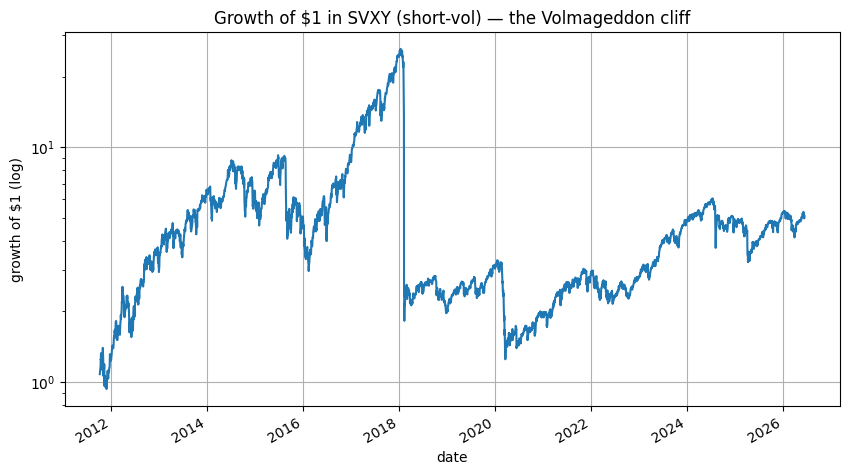

In [2]:
rows={'SVXY (short-vol)':st.summary(ret['SVXY']),'SPY (market)':st.summary(ret['SPY'])}
display(pd.DataFrame(rows).T[['cagr','sharpe','vol_ann','max_drawdown','skew','worst_day']].round(3))
eqV=(1+ret['SVXY']).cumprod()
ax=eqV.plot(title='Growth of $1 in SVXY (short-vol) — the Volmageddon cliff',lw=1.5)
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); plt.show()

## 4 · The teardown — the steamroller

A little every day; then a handful of days take almost everything.

In [3]:
wd,wdt=st.worst_day(ret['SVXY'])
print(f"median day: {c['median_day_bp']:+.0f} bp (the carry)")
print(f"worst day:  {wd:+.0%} on {wdt.date()} (Volmageddon)")
print(f"{c['n_crash_days']} crash days (<-20%) wiped {c['crash_days_total']:+.0%} between them")
post=ret.loc['2018-05-01':]; s=st.summary(post['SVXY'])
print(f"post-Volmageddon (de-levered): CAGR {s['cagr']:+.1%}, Sharpe {s['sharpe']:.2f} — the carry resumes")

median day: +40 bp (the carry)
worst day:  -83% on 2018-02-06 (Volmageddon)
5 crash days (<-20%) wiped -95% between them
post-Volmageddon (de-levered): CAGR +10.1%, Sharpe 0.45 — the carry resumes


**Read it plainly.** You collect ~40 bp on a quiet day and hand back 95% across five bad ones. The carry is real; the tail is total. That's the steamroller.

## 5 · The verdict

**Signal: Real** — the vol premium pays. **Tradability: Fragile** — skew −4.8, −95% drawdown. **Naive short-vol survives?: Busted** (the 1× funds were liquidated).

## 6 · Could you actually trade it?

Only *sized small and tail-hedged* — never bought and held. The premium is genuine, but it compensates a catastrophe; harvest it like insurance underwriting (small line, capped loss), not like a yield product. See [27 Steamroller](../../27-steamroller/).

## 7 · Going further 🚪

The carry-with-a-tail sibling of [27 Steamroller](../../27-steamroller/) (FX) and [59 Downhill](../../59-downhill/) (duration); the *honest* version of the income story [62 Premium-Seller](../../62-premium-seller/) sells badly.